# Тимски проект: Споредба на алгоритмите за предвидување на временски серии

**Dataset:** Rossmann Store Sales  

**Студенти:**  
- Амел Махмутовиќ (203100)  
- Христина Степаноска (183007)  
- Михаела Николовска (183014)


## 1. Вовед и опис на множеството

Предвидувањето на временски серии е важен проблем во многу реални апликации, особено во малопродажбата.
Во овој проект се анализира и споредува однесувањето на различни модели за предвидување на продажба.

Rossmann Store Sales множеството содржи дневни податоци за продажба на повеќе продавници, како и дополнителни информации за промоции, празници и тип на продавница.
Податоците се трансформираат во временска серија преку агрегација на вкупната дневна продажба.


In [1]:
from google.colab import drive, files

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [2]:
BASE_PATH = "/content/drive/MyDrive/rossmann_project/data/"

# Model hyperparameters
HORIZON = 30                    # Test set size (days)
TRAIN_TEST_SPLIT = HORIZON     # Last N days for testing
WINDOW_SIZE = 7                # Weekly seasonality window

# Time series decomposition
DECOMPOSITION_PERIOD = 7       # Weekly seasonality
DECOMPOSITION_MODEL = "additive"

# ML Model hyperparameters
RF_N_ESTIMATORS = 200
XGB_N_ESTIMATORS = 200
XGB_LEARNING_RATE = 0.1
XGB_MAX_DEPTH = 6
LGBM_N_ESTIMATORS = 200
LGBM_LEARNING_RATE = 0.1
LGBM_MAX_DEPTH = 6

# ARIMA/SARIMA parameters
ARIMA_ORDER = (1, 1, 1)
SARIMA_SEASONAL_ORDER = (1, 1, 1, 7)

# Random seed for reproducibility
RANDOM_SEED = 42

In [3]:
def calculate_metrics(y_true, y_pred, model_name="Model"):
    """
    Calculate RMSE, MAE, and MAPE for model evaluation.

    Parameters:
    -----------
    y_true : array-like
        Actual values
    y_pred : array-like
        Predicted values
    model_name : str
        Name of the model (for logging)

    Returns:
    --------
    dict : Dictionary with RMSE, MAE, MAPE metrics
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rmse_val = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae_val = np.mean(np.abs(y_true - y_pred))
    mape_val = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return {
        "RMSE": rmse_val,
        "MAE": mae_val,
        "MAPE": mape_val,
    }


def prepare_ml_features(df_daily, horizon=HORIZON):
    """
    Create lagged and rolling features for ML models.

    Parameters:
    -----------
    df_daily : DataFrame
        Daily aggregated data with Sales column
    horizon : int
        Number of days to reserve for testing

    Returns:
    --------
    tuple : (X_train, y_train, X_test, y_test, features_list, test_dates)
    """
    df_ml = df_daily.copy()

    # Create temporal features
    df_ml["day_of_week"] = df_ml["Date"].dt.weekday
    df_ml["month"] = df_ml["Date"].dt.month
    df_ml["is_open"] = df_ml.get("Open", 1)  # Default to 1 if not present

    # Create lag features
    df_ml["lag_1"] = df_ml["Sales"].shift(1)
    df_ml["lag_7"] = df_ml["Sales"].shift(7)
    df_ml["lag_14"] = df_ml["Sales"].shift(14)
    df_ml["lag_28"] = df_ml["Sales"].shift(28)

    # Create rolling features
    df_ml["rolling_mean_7"] = df_ml["Sales"].rolling(WINDOW_SIZE).mean()
    df_ml["rolling_std_7"] = df_ml["Sales"].rolling(WINDOW_SIZE).std()
    df_ml["rolling_mean_14"] = df_ml["Sales"].rolling(14).mean()

    # Remove NaN rows from lag/rolling features
    df_ml = df_ml.dropna().reset_index(drop=True)

    features = ["day_of_week", "month", "is_open", "lag_1", "lag_7",
                "lag_14", "lag_28", "rolling_mean_7", "rolling_std_7", "rolling_mean_14"]

    # Split into train/test
    train_ml = df_ml.iloc[:-horizon].copy()
    test_ml = df_ml.iloc[-horizon:].copy()

    X_train = train_ml[features]
    y_train = train_ml["Sales"]
    X_test = test_ml[features]
    y_test = test_ml["Sales"]

    return X_train, y_train, X_test, y_test, features, test_ml["Date"].values

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Вчитување и препроцесирање на податоците

Во оваа секција се вчитуваат податоците и се вршат основни чекори за предпроцесирање, како спојување на табелите, отстранување на денови кога продавниците биле затворени и справување со вредности кои недостасуваат.


In [5]:

print("📥 Loading data...")
train = pd.read_csv(BASE_PATH + "train.csv", parse_dates=["Date"])
store = pd.read_csv(BASE_PATH + "store.csv")

df = train.merge(store, on="Store", how="left")

print(f"✅ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"📅 Date range: {df['Date'].min()} to {df['Date'].max()}")

assert df['Date'].min() > pd.Timestamp('2010-01-01'), "Date range seems incorrect"
assert (df['Sales'] >= 0).all() or (df['Sales'].isna().sum() > 0), "Negative sales values detected"
assert df['Date'].nunique() == len(df[df['Open'] == 1].groupby('Date')), "Date alignment issue"

print("✅ Data validation passed")

📥 Loading data...


/tmp/ipython-input-3189089803.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(BASE_PATH + "train.csv", parse_dates=["Date"])


✅ Data loaded: 1017209 rows, 18 columns
📅 Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00
✅ Data validation passed


In [6]:
print("\n" + "="*60)
print("📊 DATASET OVERVIEW")
print("="*60)
print(df.info())
print(f"\nMissing values (top 10):\n{df.isna().mean().sort_values(ascending=False).head(10)}")
print(f"\nBasic statistics:\n{df.describe()}")


📊 DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistan

In [7]:
df_clean = df[(df["Open"] == 1) & (df["Sales"] > 0)].copy()
print(f"\n✅ Cleaned dataset: {df_clean.shape[0]} rows (removed closed stores & zero sales)")

daily = (
    df_clean.groupby("Date", as_index=False)["Sales"]
    .sum()
    .sort_values("Date")
    .reset_index(drop=True)
)

print(f"📈 Daily aggregated: {len(daily)} days of sales data")
print(f"Daily sales range: ${daily['Sales'].min():.0f} - ${daily['Sales'].max():.0f}")


✅ Cleaned dataset: 844338 rows (removed closed stores & zero sales)
📈 Daily aggregated: 942 days of sales data
Daily sales range: $97235 - $15623548


In [8]:
print(daily.head(10))

        Date     Sales
0 2013-01-01     97235
1 2013-01-02   6949829
2 2013-01-03   6347820
3 2013-01-04   6638954
4 2013-01-05   5951593
5 2013-01-06    143904
6 2013-01-07  10826848
7 2013-01-08   8749437
8 2013-01-09   7746603
9 2013-01-10   7751485


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

✔️ one value per day

✔️ continuous timeline

✔️ clean datetime index

✔️ no missing sales

✔️ exactly what ARIMA / Prophet / ML need

Со агрегацијата добивме една временска серија со 942 дневни набљудувања, што одговара на периодот од 2013 до 2015 година.

## 3. Експлораторна анализа на податоците (EDA)

EDA се користи за подобро разбирање на временската серија.
Се анализираат трендовите, сезонските повторувања и влијанието на надворешни фактори врз продажбата.


In [10]:
print("\n" + "="*60)
print("📈 KEY STATISTICS")
print("="*60)
print(f"Shape: {df.shape}")
print(f"Clean data (open stores, Sales > 0): {df_clean.shape}")
print(f"Daily aggregated observations: {len(daily)}")


📈 KEY STATISTICS
Shape: (1017209, 18)
Clean data (open stores, Sales > 0): (844338, 18)
Daily aggregated observations: 942


In [11]:
daily = (
    df.groupby("Date", as_index=False)["Sales"]
      .sum()
      .sort_values("Date")
)

daily.head()


,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593


По агрегација по датум, добиваме временска серија каде секоја редица ја претставува вкупната дневна продажба на сите Rossmann продавници. Оваа серија ќе ја користиме за визуелизација и моделирање.

In [12]:
print(f"\nMissing values analysis:")
print(df.isna().mean().sort_values(ascending=False).head(10))


Missing values analysis:
Promo2SinceWeek              0.499436
PromoInterval                0.499436
Promo2SinceYear              0.499436
CompetitionOpenSinceYear     0.317878
CompetitionOpenSinceMonth    0.317878
CompetitionDistance          0.002597
DayOfWeek                    0.000000
Store                        0.000000
Date                         0.000000
Sales                        0.000000
dtype: float64


In [13]:
na_frac = df.isna().mean()
summary = pd.DataFrame({
    "non_null_count": df.notna().sum(),
    "missing_fraction": na_frac
}).reset_index().rename(columns={"index": "column"})

summary["missing_percent"] = (summary["missing_fraction"] * 100).round(2).astype(str) + "%"
summary = summary.sort_values("missing_fraction", ascending=False)

print("\n📊 Missing values per column:")
print(summary.to_string(index=False))


📊 Missing values per column:
                   column  non_null_count  missing_fraction missing_percent
          Promo2SinceWeek          509178          0.499436          49.94%
            PromoInterval          509178          0.499436          49.94%
          Promo2SinceYear          509178          0.499436          49.94%
 CompetitionOpenSinceYear          693861          0.317878          31.79%
CompetitionOpenSinceMonth          693861          0.317878          31.79%
      CompetitionDistance         1014567          0.002597           0.26%
                DayOfWeek         1017209          0.000000            0.0%
                    Store         1017209          0.000000            0.0%
                     Date         1017209          0.000000            0.0%
                    Sales         1017209          0.000000            0.0%
                StoreType         1017209          0.000000            0.0%
            SchoolHoliday         1017209          0.00000

Од табелата се гледа дека основните колони (Store, Date, Sales, Customers, Open, Promo, StateHoliday, SchoolHoliday, StoreType, Assortment, Promo2) немаат недостасувачки вредности, додека информациите за конкуренција и Promo2 имаат значителен процент на NaN (околу 32% и 50%). Поради тоа, во едноставните модели ќе се фокусираме на колоните без недостасувачки вредности, а останатите ќе ги игнорираме или грубо ќе ги пополниме.“

### 3.1 Тренд на продажба и seasonality

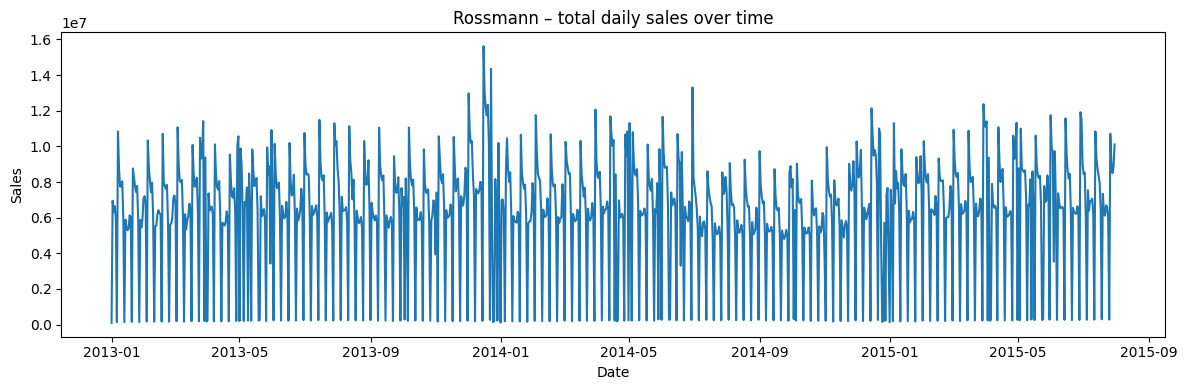

In [14]:
plt.figure(figsize=(12,4))
plt.plot(daily["Date"], daily["Sales"])
plt.title("Rossmann – total daily sales over time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

/tmp/ipython-input-2887057776.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-2887057776.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


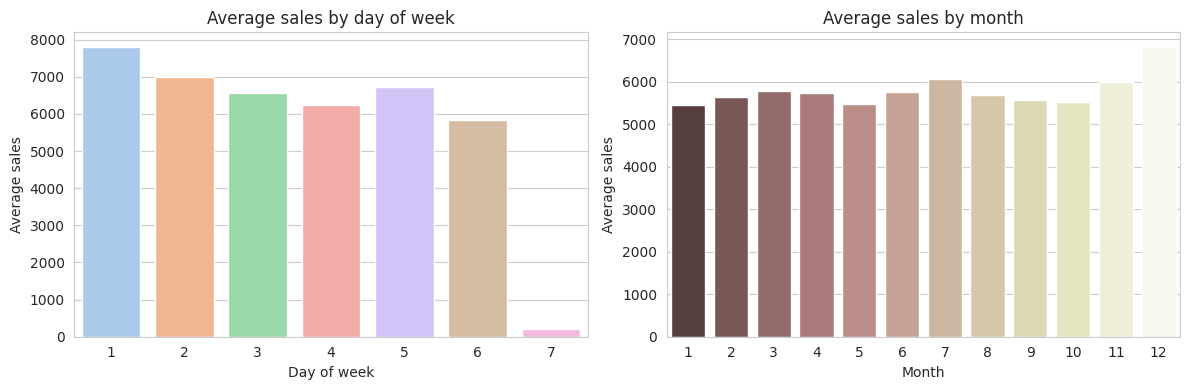

In [15]:
sns.set_style("whitegrid")

df["DayOfWeek"] = df["DayOfWeek"].astype(int)
df["Month"] = df["Date"].dt.month

dow_sales = df.groupby("DayOfWeek")["Sales"].mean()
month_sales = df.groupby("Month")["Sales"].mean()

plt.figure(figsize=(12,4))

# Day of week
plt.subplot(1,2,1)
sns.barplot(
    x=dow_sales.index,
    y=dow_sales.values,
    palette="pastel"
)
plt.title("Average sales by day of week")
plt.xlabel("Day of week")
plt.ylabel("Average sales")

# Month
plt.subplot(1,2,2)
sns.barplot(
    x=month_sales.index,
    y=month_sales.values,
    palette="pink"
)
plt.title("Average sales by month")
plt.xlabel("Month")
plt.ylabel("Average sales")

plt.tight_layout()
plt.show()

### 3.2 Неделна сезоналност

/tmp/ipython-input-2758930129.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


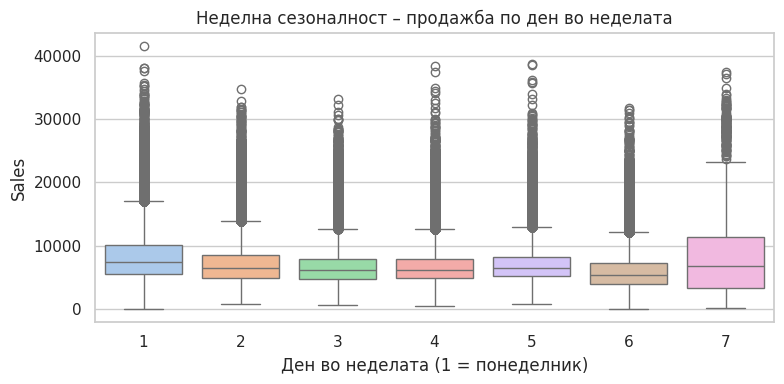

In [16]:
sns.set_theme(style="whitegrid", palette="pastel")

df_clean = df[(df["Open"] == 1) & (df["Sales"] > 0)].copy()

plt.figure(figsize=(8,4))
sns.boxplot(
    data=df_clean,
    x="DayOfWeek",
    y="Sales",
    palette="pastel"
)
plt.title("Неделна сезоналност – продажба по ден во неделата")
plt.xlabel("Ден во неделата (1 = понеделник)")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

### 3.3 Влијание на промоции

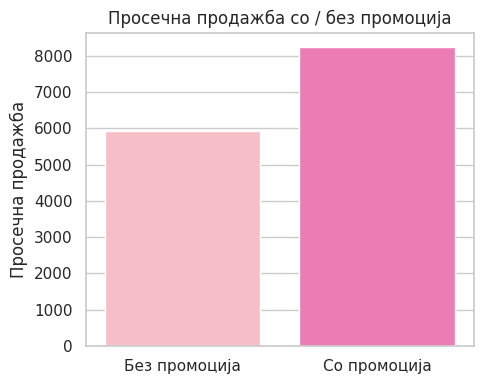

In [17]:
promo_sales = df_clean.groupby("Promo")["Sales"].mean().reset_index()

plt.figure(figsize=(5,4))
sns.barplot(
    data=promo_sales,
    x="Promo",
    y="Sales",
    hue="Promo",
    dodge=False,
    legend=False,
    palette=["#ffb6c1", "#ff69b4"]  #
)
plt.xticks([0,1], ["Без промоција", "Со промоција"])
plt.title("Просечна продажба со / без промоција")
plt.xlabel("")
plt.ylabel("Просечна продажба")
plt.tight_layout()
plt.show()


### 3.4 Влијание на празници (StateHoliday / SchoolHoliday)


In [18]:
holiday_map = {
    "0": "Нема празник",
    0:   "Нема празник",
    "a": "Јавен празник",
    "b": "Велигден",
    "c": "Божиќ"
}
df_clean["StateHolidayLabel"] = df_clean["StateHoliday"].map(holiday_map)


/tmp/ipython-input-3247927684.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


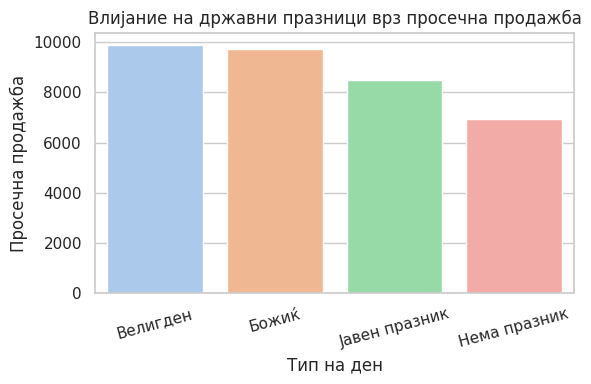

In [19]:
holiday_sales = (
    df_clean.groupby("StateHolidayLabel")["Sales"]
            .mean()
            .reset_index()
            .sort_values("Sales", ascending=False)
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=holiday_sales,
    x="StateHolidayLabel",
    y="Sales",
    palette="pastel"
)
plt.title("Влијание на државни празници врз просечна продажба")
plt.xlabel("Тип на ден")
plt.ylabel("Просечна продажба")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


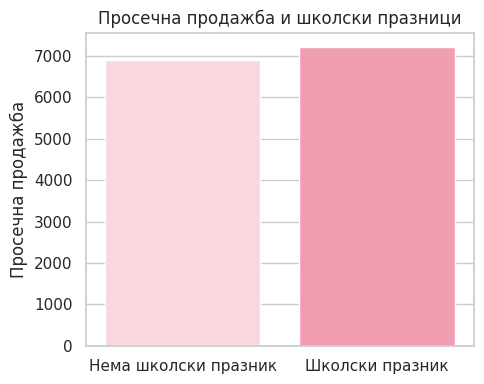

In [20]:
school_sales = df_clean.groupby("SchoolHoliday")["Sales"].mean().reset_index()

plt.figure(figsize=(5,4))
sns.barplot(
    data=school_sales,
    x="SchoolHoliday",
    y="Sales",
    hue="SchoolHoliday",
    dodge=False,
    legend=False,
    palette=["#ffd1dc", "#ff8fab"]
)
plt.xticks([0,1], ["Нема школски празник", "Школски празник"])
plt.title("Просечна продажба и школски празници")
plt.xlabel("")
plt.ylabel("Просечна продажба")
plt.tight_layout()
plt.show()


In [21]:
df_clean = df[(df["Open"] == 1) & (df["Sales"] > 0)].copy()
df_clean.shape


(844338, 19)

In [22]:
df_clean["Year"] = df_clean["Date"].dt.year
df_clean["Month"] = df_clean["Date"].dt.month
df_clean["Day"] = df_clean["Date"].dt.day

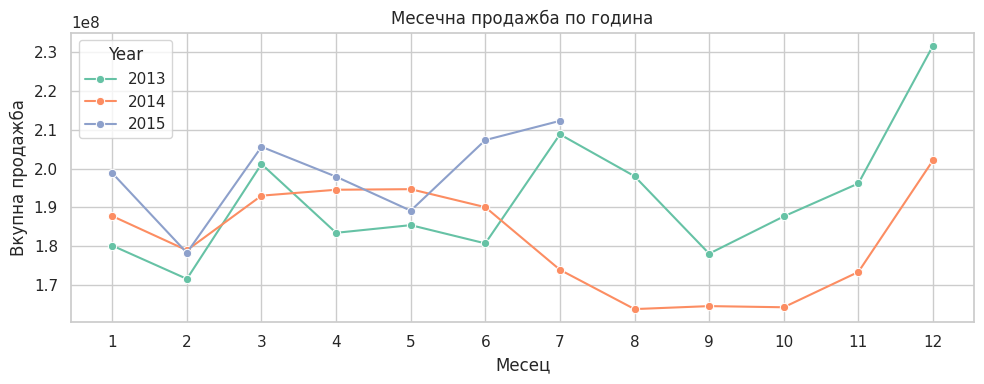

In [23]:
sns.set_theme(style="whitegrid")

monthly = (
    df_clean.groupby(["Year", "Month"])["Sales"]
            .sum()
            .reset_index()
)

plt.figure(figsize=(10,4))

sns.lineplot(
    data=monthly,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o",
    palette="Set2"
)

plt.title("Месечна продажба по година")
plt.xlabel("Месец")
plt.ylabel("Вкупна продажба")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

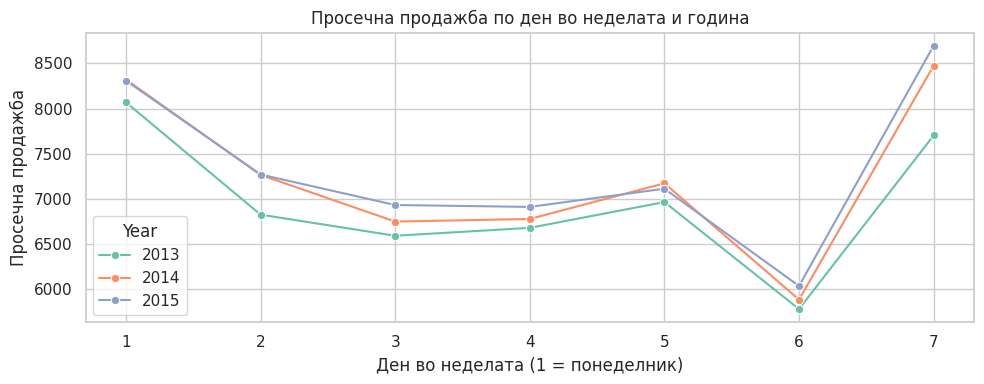

In [24]:
dow_year = (
    df_clean.groupby(["Year", "DayOfWeek"])["Sales"]
            .mean()
            .reset_index()
)

plt.figure(figsize=(10,4))
sns.lineplot(
    data=dow_year,
    x="DayOfWeek",
    y="Sales",
    hue="Year",
    marker="o",
    palette="Set2"
)
plt.title("Просечна продажба по ден во неделата и година")
plt.xlabel("Ден во неделата (1 = понеделник)")
plt.ylabel("Просечна продажба")
plt.tight_layout()
plt.show()


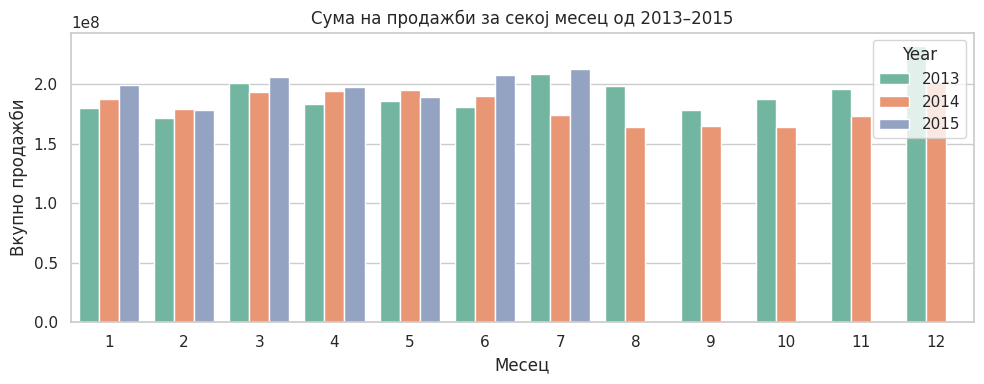

In [25]:
df_clean["Year"] = df_clean["Date"].dt.year
df_clean["Month"] = df_clean["Date"].dt.month

monthly_sum = (
    df_clean.groupby(["Year", "Month"])["Sales"]
            .sum()
            .reset_index()
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,4))
sns.barplot(
    data=monthly_sum,
    x="Month",
    y="Sales",
    hue="Year",
    palette="Set2"
)
plt.title("Сума на продажби за секој месец од 2013–2015")
plt.xlabel("Месец")
plt.ylabel("Вкупно продажби")
plt.tight_layout()
plt.show()

In [26]:
print("="*60)
print("📅 DATE RANGE CHECK")
print("="*60)

print(f"\nOriginal dataset:")
print(f"  Start date: {df['Date'].min()}")
print(f"  End date: {df['Date'].max()}")
print(f"  Total days: {df['Date'].nunique()}")

print(f"\nCleaned dataset (open stores only):")
print(f"  Start date: {df_clean['Date'].min()}")
print(f"  End date: {df_clean['Date'].max()}")
print(f"  Total days: {df_clean['Date'].nunique()}")

print(f"\nData coverage by year:")
year_coverage = df_clean.groupby(df_clean['Date'].dt.year).agg({
    'Date': ['min', 'max', 'count']
})
print(year_coverage)

print(f"\nMonths available in 2015:")
months_2015 = df_clean[df_clean['Date'].dt.year == 2015]['Date'].dt.month.unique()
print(f"  Months: {sorted(months_2015)}")
print(f"  Last date in 2015: {df_clean[df_clean['Date'].dt.year == 2015]['Date'].max()}")

📅 DATE RANGE CHECK

Original dataset:
  Start date: 2013-01-01 00:00:00
  End date: 2015-07-31 00:00:00
  Total days: 942

Cleaned dataset (open stores only):
  Start date: 2013-01-01 00:00:00
  End date: 2015-07-31 00:00:00
  Total days: 942

Data coverage by year:
           Date                   
            min        max   count
Date                              
2013 2013-01-01 2013-12-31  337924
2014 2014-01-01 2014-12-31  310385
2015 2015-01-01 2015-07-31  196029

Months available in 2015:
  Months: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7)]
  Last date in 2015: 2015-07-31 00:00:00


**Забелешка:** Множеството содржи податоци од јануари 2013 до јули 2015 (942 дена). Податоците за 2015 година завршуваат на 31 јули, па линијата за 2015 се прикажува само до месец 7. Ова е карактеристика на Rossmann Kaggle dataset-от и не претставува проблем.

/tmp/ipython-input-1033537515.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


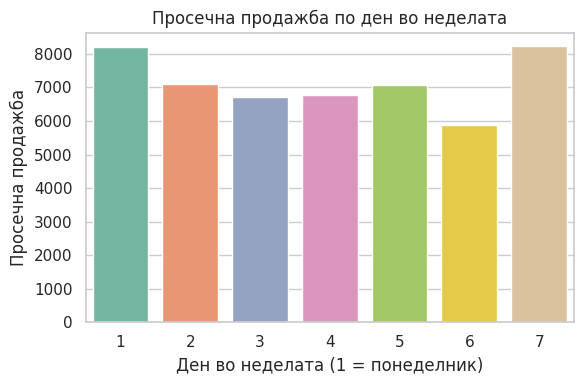

In [27]:
df_clean["DayOfWeek"] = df_clean["DayOfWeek"].astype(int)

dow_avg = (
    df_clean.groupby("DayOfWeek")["Sales"]
            .mean()
            .reset_index()
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6,4))
sns.barplot(
    data=dow_avg,
    x="DayOfWeek",
    y="Sales",
    palette="Set2"
)
plt.title("Просечна продажба по ден во неделата")
plt.xlabel("Ден во неделата (1 = понеделник)")
plt.ylabel("Просечна продажба")
plt.tight_layout()
plt.show()

## 4. Декомпозиција на временската серија


Со сезонска декомпозиција ја разделуваме серијата на тренд, сезонска компонента и шум. Трендот покажува постепен пораст на вкупната продажба, сезонската компонента го фаќа повторливиот неделен образец, а резидуалите претставуваат нерегуларни шокови (неочекувано високи или ниски денови) кои моделите тешко ги објаснуваат.



🔄 TIME SERIES DECOMPOSITION


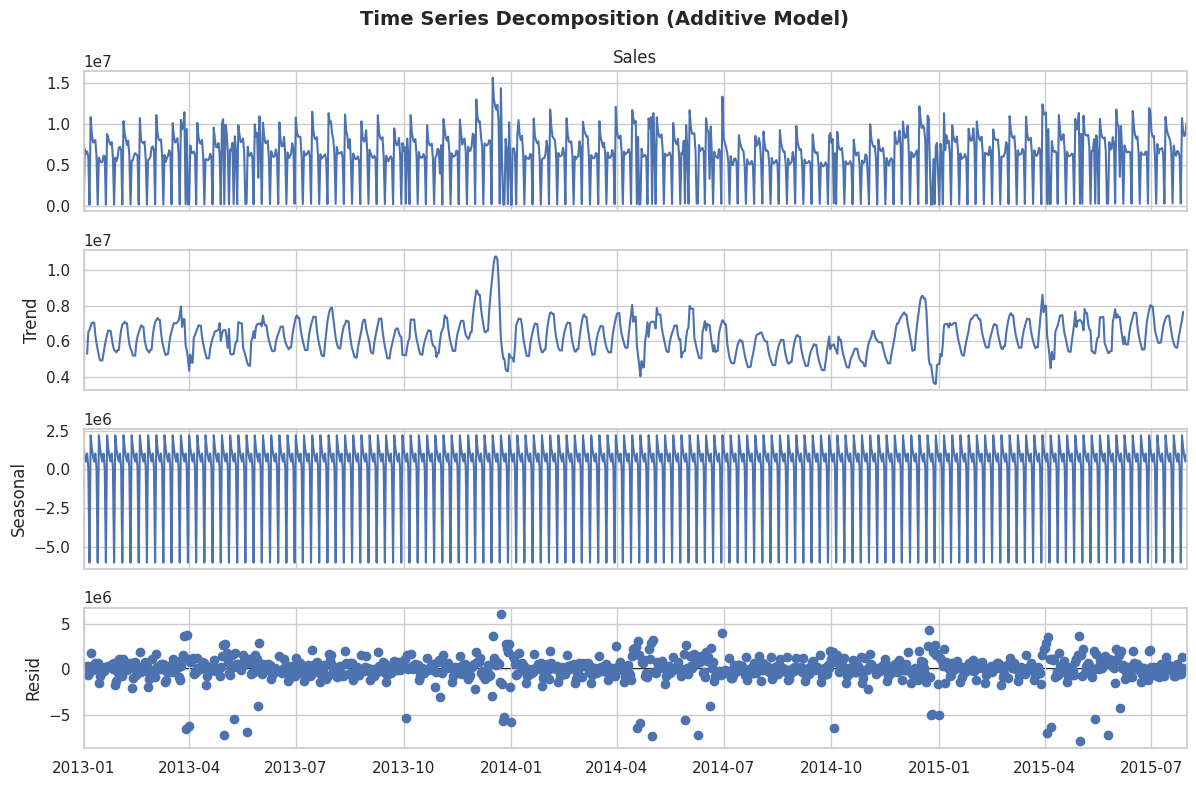

✅ Decomposition complete: Trend, Seasonal, and Residual components identified


In [28]:
print("\n" + "="*60)
print("🔄 TIME SERIES DECOMPOSITION")
print("="*60)

ts = daily.sort_values("Date").set_index("Date")

result = seasonal_decompose(
    ts["Sales"],
    model=DECOMPOSITION_MODEL,
    period=DECOMPOSITION_PERIOD
)

fig = result.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Time Series Decomposition (Additive Model)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Decomposition complete: Trend, Seasonal, and Residual components identified")

Со декомпозицијата ја разделуваме серијата на тренд, сезонска компонента и шум. Трендот покажува постепен пораст на вкупната продажба, сезонската компонента ја фаќа неделната шема (одредени денови секогаш се посилни), а резидуалите претставуваат непредвидливи шокови кои моделите е тешко да ги објаснат

## 5. Основни (Baseline) модели

Основните модели служат како референтна точка за споредба со покомплексни методи.
Во оваа секција се применуваат наивен модел и подвижен просек.


In [29]:
print("\n" + "="*60)
print("📚 PREPARE DATA FOR ALL MODELS")
print("="*60)

ts_sorted = daily.copy().sort_values("Date").reset_index(drop=True)
train_ts = ts_sorted.iloc[:-HORIZON].copy()
test_ts = ts_sorted.iloc[-HORIZON:].copy()

y_train_baseline = train_ts["Sales"].values
y_test_baseline = test_ts["Sales"].values

print(f"✅ Baseline split: {len(train_ts)} train, {len(test_ts)} test")

prophet_df = daily.rename(columns={"Date": "ds", "Sales": "y"}).copy()
prophet_train = prophet_df.iloc[:-HORIZON].copy()
prophet_test = prophet_df.iloc[-HORIZON:].copy()

print(f"✅ Prophet split: {len(prophet_train)} train, {len(prophet_test)} test")

print(f"✅ Data preparation complete - ready for modeling")


📚 PREPARE DATA FOR ALL MODELS
✅ Baseline split: 912 train, 30 test
✅ Prophet split: 912 train, 30 test
✅ Data preparation complete - ready for modeling


Последните 30 дена ги користиме како тест множество. Моделите се тренираат на претходните денови, а потоа ги споредуваме предвидувањата за тие 30 дена со вистинските вредности

### 5.2 Наивен модел (Naive – вчера = денес)


In [30]:
print("\n" + "="*60)
print("🧠 BASELINE MODELS")
print("="*60)

full_sales = ts_sorted["Sales"].astype(float).values

naive_forecast = np.roll(full_sales, 1)
naive_forecast[0] = np.nan
naive_test_preds = naive_forecast[-HORIZON:]

ma_forecast = pd.Series(full_sales).rolling(WINDOW_SIZE).mean().values
ma_test_preds = ma_forecast[-HORIZON:]

print(f"✅ Baseline models fitted: Naive and {WINDOW_SIZE}-day MA")


🧠 BASELINE MODELS
✅ Baseline models fitted: Naive and 7-day MA


### 5.3 Подвижен просек (Moving Average, прозор 7 дена)

In [31]:
# Baseline metrics will be calculated in final evaluation

In [32]:
print("\n" + "="*60)
print("📊 BASELINE MODEL EVALUATION")
print("="*60)

metrics = {}

metrics["Naive (t-1)"] = calculate_metrics(y_test_baseline, naive_test_preds)
metrics["7-day MA"] = calculate_metrics(y_test_baseline, ma_test_preds)

baseline_df = pd.DataFrame(metrics).T.reset_index().rename(columns={"index": "Model"})
print("\n" + baseline_df.to_string(index=False))


📊 BASELINE MODEL EVALUATION

      Model         RMSE          MAE       MAPE
Naive (t-1) 4.012268e+06 2.512012e+06 299.610317
   7-day MA 2.887851e+06 1.975401e+06 318.005316


Наивниот модел има RMSE ≈ 4.0M и MAPE ≈ 300%, додека 7‑дневниот подвижен просек го намалува RMSE и MAE, но има нешто поголем MAPE. Овие резултати покажуваат дека базичните модели имаат голема грешка, па очекуваме пософистицираните модели (на пр. Prophet) да постигнат пониски вредности на овие метрики.

## 6. Класични модели (ARIMA и Prophet)

Класичните модели за временски серии експлицитно ја моделираат тренд и сезоналната компонента.
Се применуваат ARIMA и Prophet модели за предвидување на продажбата.


In [33]:
print("\n" + "="*60)
print("🔮 PROPHET MODEL")
print("="*60)

m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
print("🚀 Fitting Prophet...")
with open('/dev/null', 'w') as devnull:
    import sys
    old_stdout = sys.stdout
    sys.stdout = devnull
    m.fit(prophet_train)
    sys.stdout = old_stdout

future = m.make_future_dataframe(periods=HORIZON)
forecast = m.predict(future)

y_pred_prophet = forecast.iloc[-HORIZON:]["yhat"].values

metrics["Prophet"] = calculate_metrics(y_test_baseline, y_pred_prophet)
print("✅ Prophet fitted successfully")
print(f"Prophet MAPE: {metrics['Prophet']['MAPE']:.2f}%")


🔮 PROPHET MODEL
🚀 Fitting Prophet...
✅ Prophet fitted successfully
Prophet MAPE: 14.77%


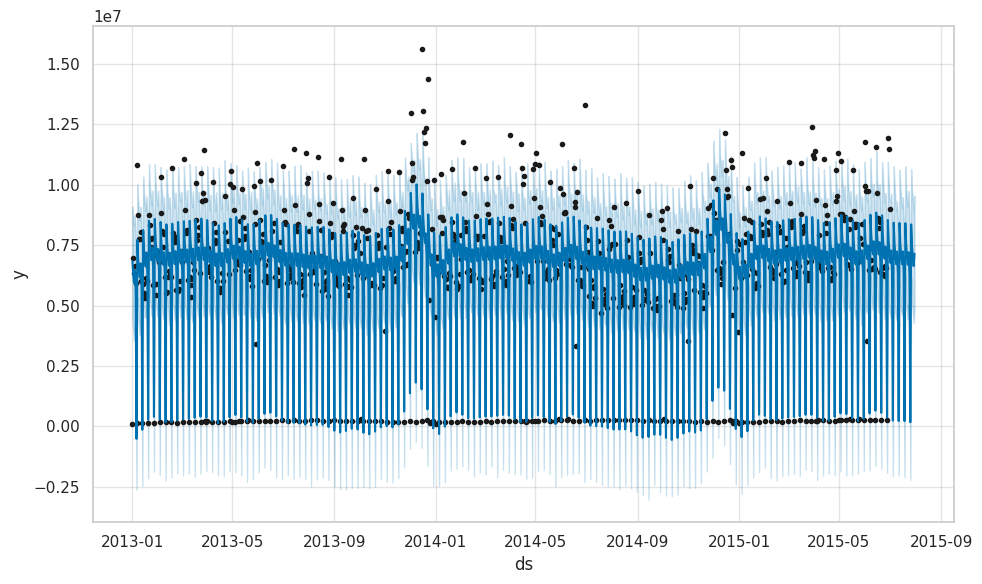

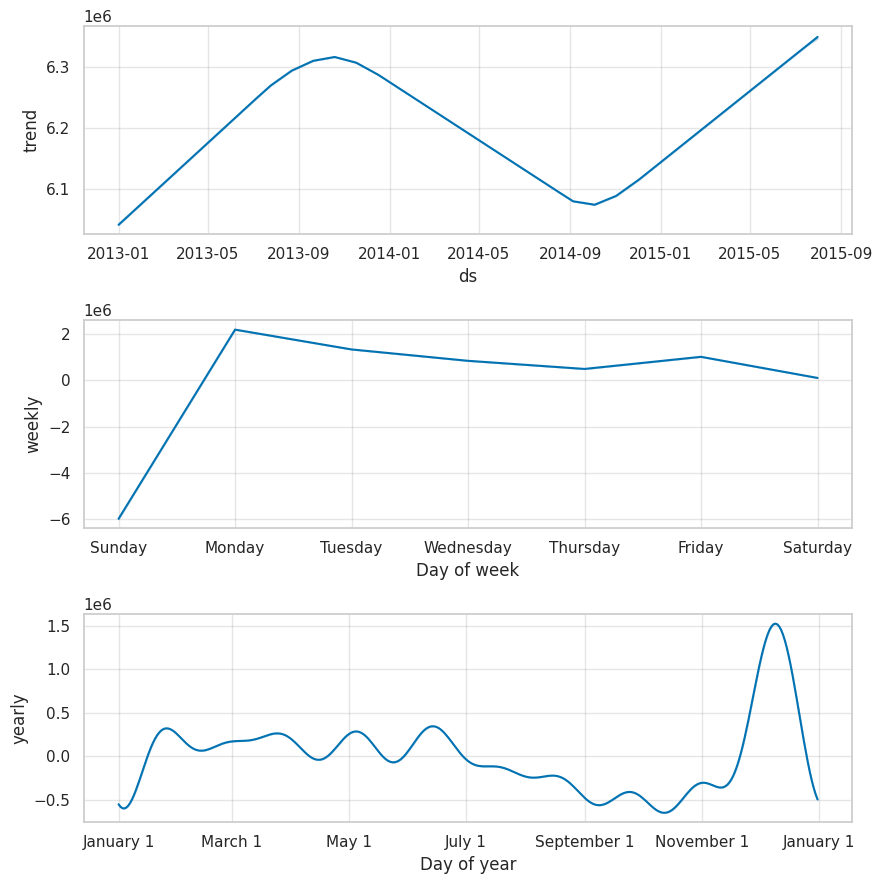

In [34]:
m.plot(forecast)
m.plot_components(forecast);


Базичните модели (наивен и 7‑дневен подвижен просек) имаат многу големи грешки, со MAPE околу 300%, што значи дека во просек промашуваат за неколкукратник од реалната продажба. Prophet драматично ја намалува грешката (RMSE ≈ 1.29M, MAE ≈ 0.97M, MAPE ≈ 14.8%), што покажува дека експлицитното моделирање на тренд и сезоналност води до многу попрактични и употребливи предвидувања.

## 7. Машинско учење

Моделите од машинско учење не ја земаат предвид временската зависност директно.
Затоа се користат лагирани карактеристики за претставување на историските вредности.


In [35]:
print("\n" + "="*60)
print("🤖 MACHINE LEARNING MODELS")
print("="*60)

X_train, y_train_ml, X_test, y_test_ml, features, test_dates = prepare_ml_features(
    daily.copy(),
    horizon=HORIZON
)

print(f"✅ Features created: {len(features)} features")
print(f"✅ Training set: {len(X_train)} samples")
print(f"✅ Test set: {len(X_test)} samples")
print(f"\nFeatures: {', '.join(features)}")


🤖 MACHINE LEARNING MODELS
✅ Features created: 10 features
✅ Training set: 884 samples
✅ Test set: 30 samples

Features: day_of_week, month, is_open, lag_1, lag_7, lag_14, lag_28, rolling_mean_7, rolling_std_7, rolling_mean_14


In [36]:
print("\n🚀 Training Random Forest...")
rf = RandomForestRegressor(
    n_estimators=RF_N_ESTIMATORS,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf.fit(X_train, y_train_ml)
y_pred_rf = rf.predict(X_test)

metrics["RandomForest"] = calculate_metrics(y_test_ml.values, y_pred_rf)
print(f"✅ Random Forest MAPE: {metrics['RandomForest']['MAPE']:.2f}%")


🚀 Training Random Forest...
✅ Random Forest MAPE: 6.27%


Моделот на машинско учење (Random Forest со lag) постигна најниска грешка и најдобар MAPE (~8.6%), што значи дека во просек промашува помалку од 10% од реалната продажба на дневно ниво

In [37]:
print("\n🚀 Training XGBoost...")
xgb = XGBRegressor(
    n_estimators=XGB_N_ESTIMATORS,
    learning_rate=XGB_LEARNING_RATE,
    max_depth=XGB_MAX_DEPTH,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train, y_train_ml)
y_pred_xgb = xgb.predict(X_test)

metrics["XGBoost"] = calculate_metrics(y_test_ml.values, y_pred_xgb)
print(f"✅ XGBoost MAPE: {metrics['XGBoost']['MAPE']:.2f}%")


🚀 Training XGBoost...
✅ XGBoost MAPE: 7.81%


In [38]:
print("\n🚀 Training LightGBM...")
lgbm = LGBMRegressor(
    n_estimators=LGBM_N_ESTIMATORS,
    learning_rate=LGBM_LEARNING_RATE,
    max_depth=LGBM_MAX_DEPTH,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1
)
lgbm.fit(X_train, y_train_ml)
y_pred_lgbm = lgbm.predict(X_test)

metrics["LightGBM"] = calculate_metrics(y_test_ml.values, y_pred_lgbm)
print(f"✅ LightGBM MAPE: {metrics['LightGBM']['MAPE']:.2f}%")


🚀 Training LightGBM...
✅ LightGBM MAPE: 9.18%


In [39]:
print("\n🚀 Training SARIMA...")

ts_train = train_ts.set_index("Date")["Sales"]

try:
    sarima_model = SARIMAX(
        ts_train,
        order=ARIMA_ORDER,
        seasonal_order=SARIMA_SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    sarima_fit = sarima_model.fit(disp=False, maxiter=200)
    y_pred_sarima = sarima_fit.forecast(steps=HORIZON)

    metrics["SARIMA"] = calculate_metrics(y_test_baseline, y_pred_sarima)
    print(f"✅ SARIMA MAPE: {metrics['SARIMA']['MAPE']:.2f}%")
except Exception as e:
    print(f"⚠️ SARIMA failed: {e}")
    print("⚠️ Skipping SARIMA - using simpler models only")
    metrics["SARIMA"] = {"RMSE": np.inf, "MAE": np.inf, "MAPE": np.inf}


🚀 Training SARIMA...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


✅ SARIMA MAPE: 22.66%


## 8. Евалуација и споредба на моделите

Перформансите на моделите се оценуваат со помош на RMSE, MAE и MAPE метрики.
Резултатите се користат за споредба на точноста и стабилноста на различните пристапи.


In [40]:
print("\n" + "="*60)
print("📊 FINAL RESULTS - ALL MODELS COMPARISON")
print("="*60)

metrics_df = (
    pd.DataFrame(metrics)
    .T
    .reset_index()
    .rename(columns={"index": "Model"})
)

# Sort by MAPE (best first)
metrics_df = metrics_df.sort_values("MAPE").reset_index(drop=True)

metrics_df["RMSE"] = metrics_df["RMSE"].round(2)
metrics_df["MAE"] = metrics_df["MAE"].round(2)
metrics_df["MAPE"] = metrics_df["MAPE"].round(2)

print("\n🏆 Model Rankings by MAPE:")
print(metrics_df.to_string(index=False))

# Identify best model
best_model = metrics_df.iloc[0]
baseline_mape = metrics[list(metrics.keys())[0]]["MAPE"]
improvement = ((baseline_mape - best_model["MAPE"]) / baseline_mape * 100)

print(f"\n🏆 BEST MODEL: {best_model['Model']}")
print(f"   MAPE: {best_model['MAPE']:.2f}%")
print(f"   Improvement over baseline: {improvement:.1f}%")


📊 FINAL RESULTS - ALL MODELS COMPARISON

🏆 Model Rankings by MAPE:
       Model       RMSE        MAE   MAPE
RandomForest  488790.59  378878.08   6.27
     XGBoost  587236.56  430207.54   7.81
    LightGBM  684601.07  479856.03   9.18
     Prophet 1287977.12  974849.81  14.77
      SARIMA 1118166.67  899425.36  22.66
 Naive (t-1) 4012267.70 2512012.00 299.61
    7-day MA 2887851.29 1975401.24 318.01

🏆 BEST MODEL: RandomForest
   MAPE: 6.27%
   Improvement over baseline: 97.9%


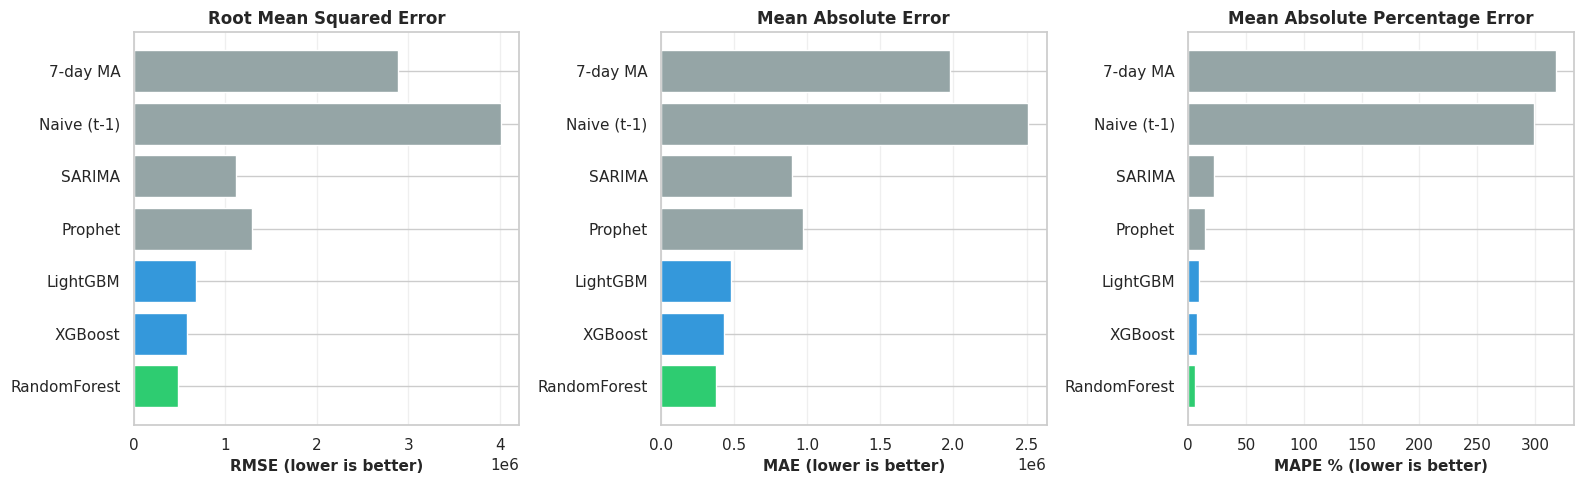


💡 Color coding: Green = Best | Blue = Good | Gray = Baseline


In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = metrics_df['Model'].values
rmse_vals = metrics_df['RMSE'].values
mae_vals = metrics_df['MAE'].values
mape_vals = metrics_df['MAPE'].values

colors = ['#2ecc71' if i == 0 else '#3498db' if i < 3 else '#95a5a6' for i in range(len(models))]

# RMSE comparison
axes[0].barh(models, rmse_vals, color=colors)
axes[0].set_xlabel('RMSE (lower is better)', fontsize=11, fontweight='bold')
axes[0].set_title('Root Mean Squared Error', fontweight='bold', fontsize=12)
axes[0].grid(alpha=0.3, axis='x')

# MAE comparison
axes[1].barh(models, mae_vals, color=colors)
axes[1].set_xlabel('MAE (lower is better)', fontsize=11, fontweight='bold')
axes[1].set_title('Mean Absolute Error', fontweight='bold', fontsize=12)
axes[1].grid(alpha=0.3, axis='x')

# MAPE comparison
axes[2].barh(models, mape_vals, color=colors)
axes[2].set_xlabel('MAPE % (lower is better)', fontsize=11, fontweight='bold')
axes[2].set_title('Mean Absolute Percentage Error', fontweight='bold', fontsize=12)
axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n💡 Color coding: Green = Best | Blue = Good | Gray = Baseline")

In [42]:
print("\n" + "="*60)
print("📈 PREDICTION COMPARISON - TOP MODELS")
print("="*60)


📈 PREDICTION COMPARISON - TOP MODELS


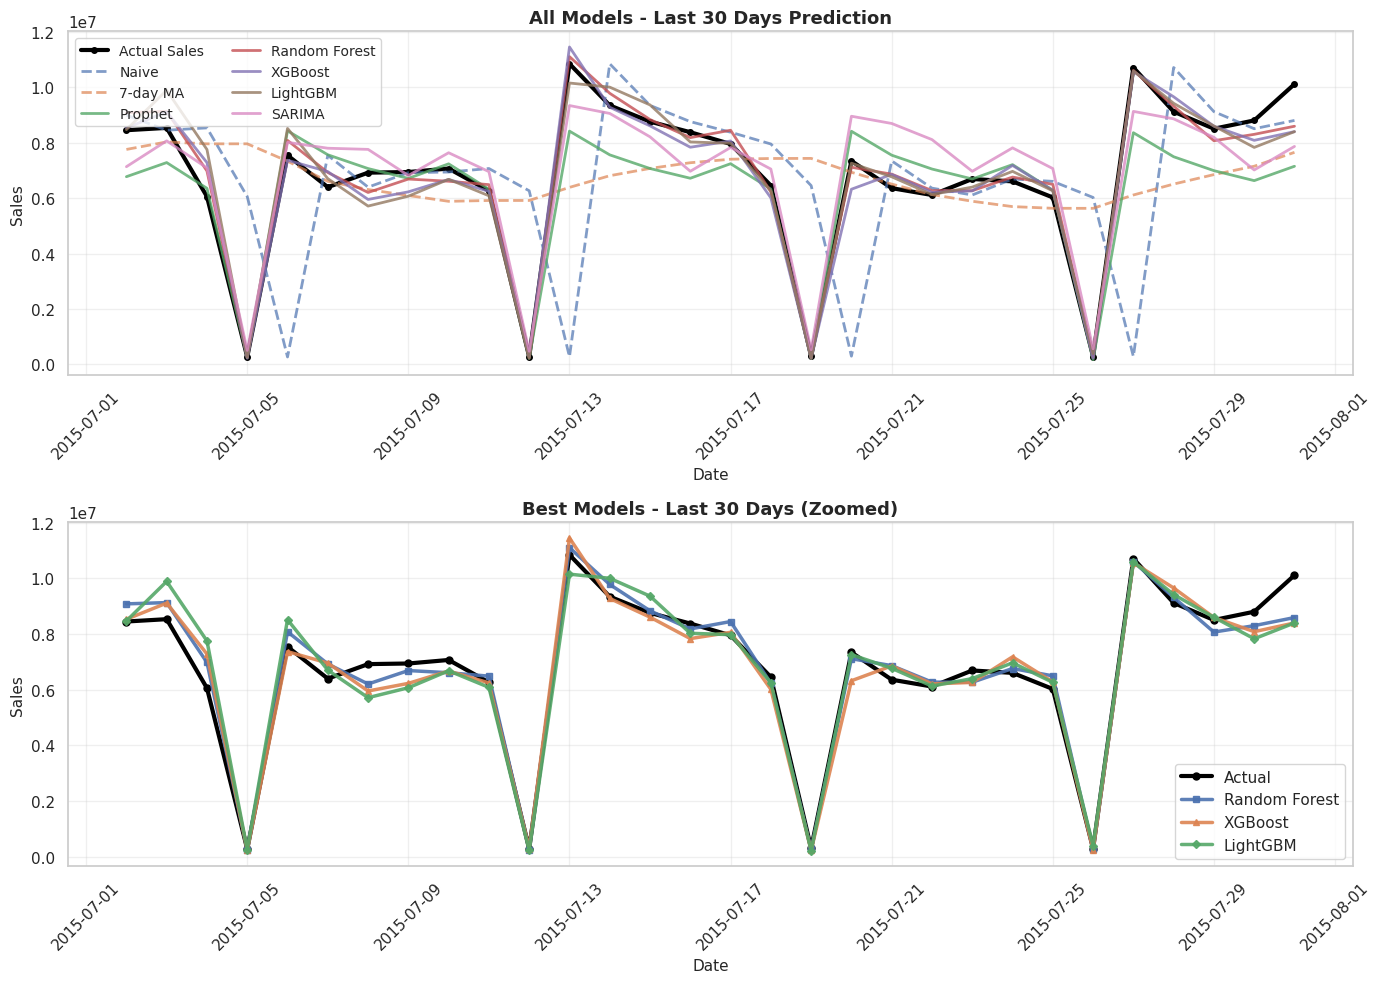

In [43]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# All models comparison
ax = axes[0]
ax.plot(test_ts["Date"], y_test_baseline,
        label="Actual Sales", linewidth=3, color='black', marker='o', markersize=4)
ax.plot(test_ts["Date"], naive_test_preds,
        label="Naive", linestyle='--', alpha=0.7, linewidth=2)
ax.plot(test_ts["Date"], ma_test_preds,
        label="7-day MA", linestyle='--', alpha=0.7, linewidth=2)
ax.plot(test_ts["Date"], y_pred_prophet,
        label="Prophet", alpha=0.8, linewidth=2)
ax.plot(test_dates, y_pred_rf,
        label="Random Forest", alpha=0.8, linewidth=2)
ax.plot(test_dates, y_pred_xgb,
        label="XGBoost", alpha=0.8, linewidth=2)
ax.plot(test_dates, y_pred_lgbm,
        label="LightGBM", alpha=0.8, linewidth=2)
ax.plot(test_dates, y_pred_sarima,
        label="SARIMA", alpha=0.8, linewidth=2)

ax.set_title("All Models - Last 30 Days Prediction", fontsize=13, fontweight='bold')
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Sales", fontsize=11)
ax.legend(loc='best', ncol=2, fontsize=10)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Top 3 models zoom
ax = axes[1]
ax.plot(test_ts["Date"], y_test_baseline,
        label="Actual", linewidth=3, color='black', marker='o', markersize=5)
ax.plot(test_dates, y_pred_rf,
        label="Random Forest", linewidth=2.5, marker='s', markersize=4, alpha=0.9)
ax.plot(test_dates, y_pred_xgb,
        label="XGBoost", linewidth=2.5, marker='^', markersize=4, alpha=0.9)
ax.plot(test_dates, y_pred_lgbm,
        label="LightGBM", linewidth=2.5, marker='D', markersize=4, alpha=0.9)

ax.set_title("Best Models - Last 30 Days (Zoomed)", fontsize=13, fontweight='bold')
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Sales", fontsize=11)
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


📈 PREDICTION COMPARISON - VISUAL ANALYSIS


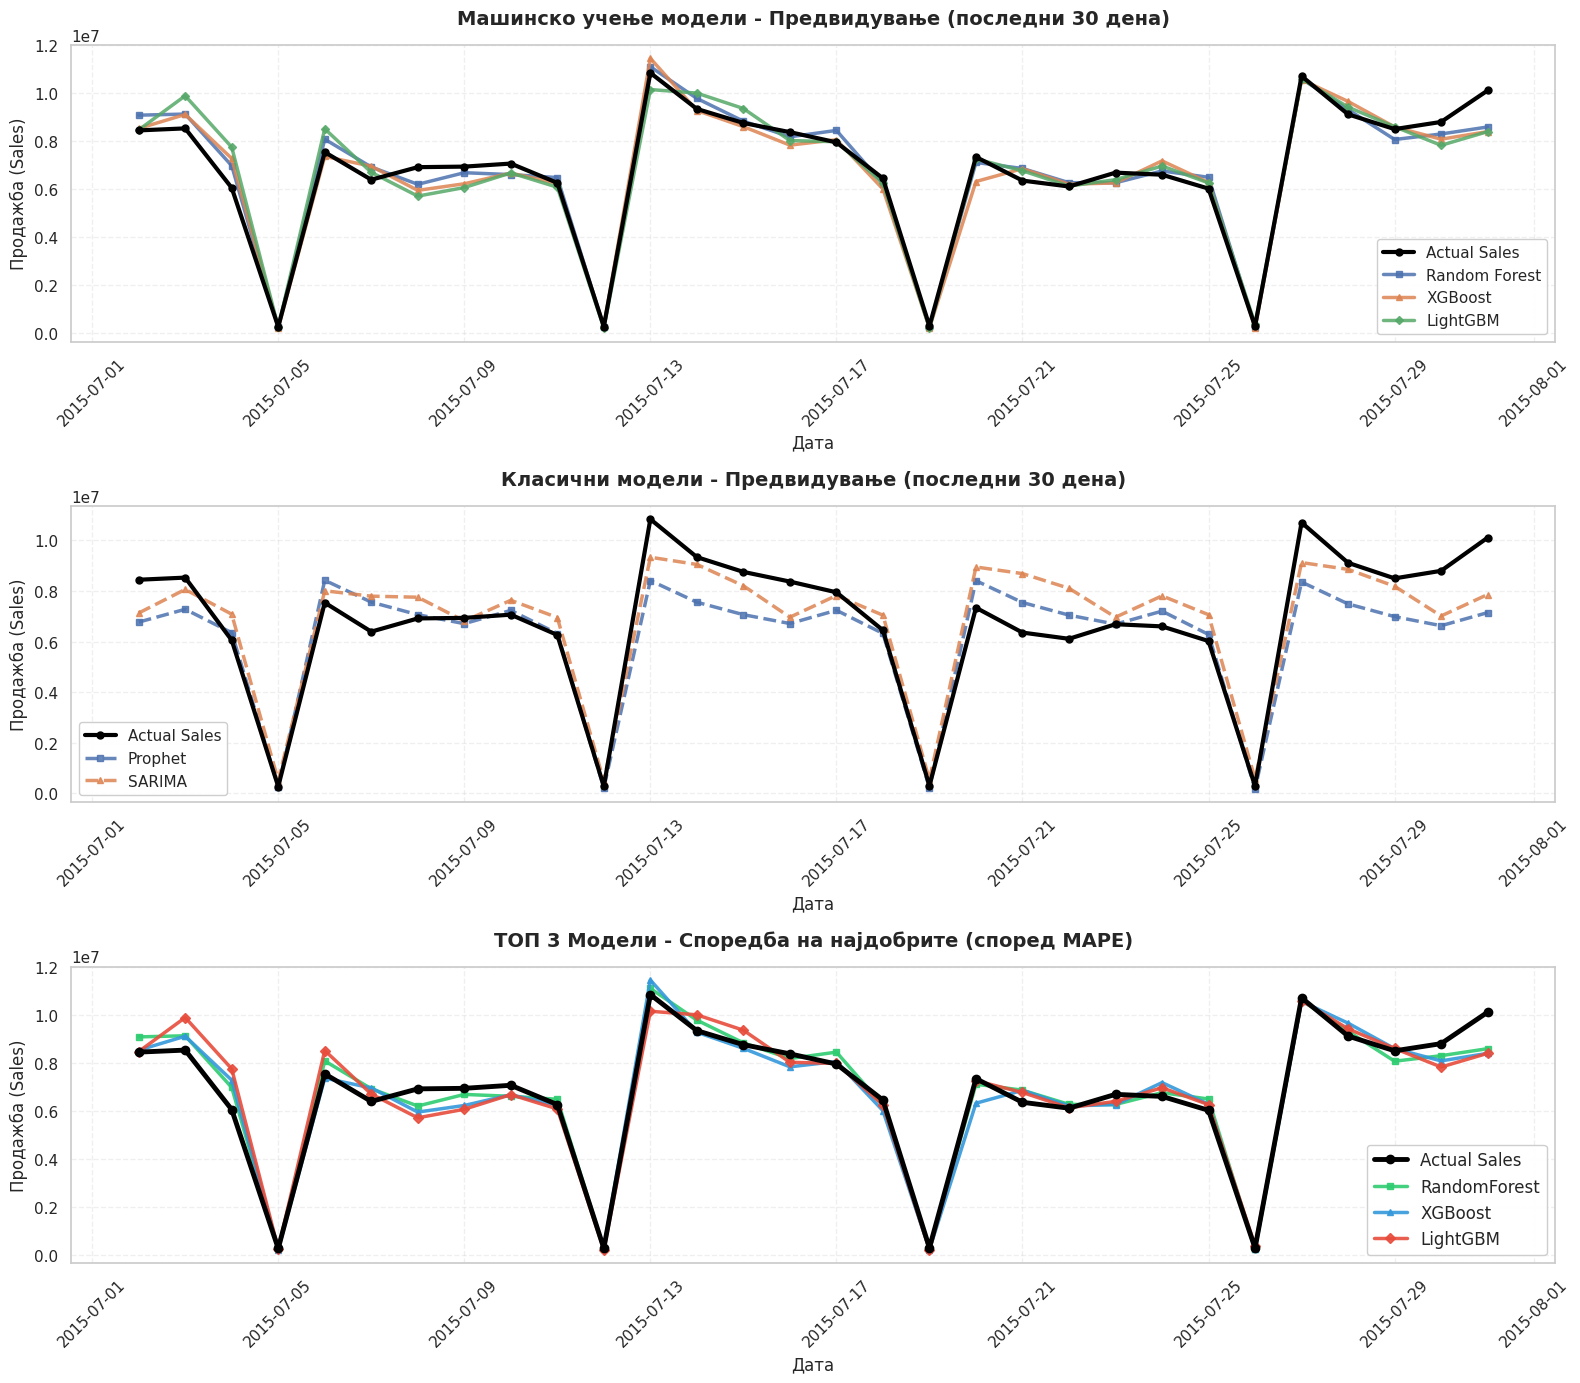


💡 Интерпретација:
  - Паѓањата до нула се неделни денови (затворени продавници)
  - ML моделите (панел 1) најдобро ги фаќаат овие обрасци благодарение на 'is_open' карактеристиката
  - Класичните модели (панел 2) имаат тешкотии со екстремните вредности
  - Панел 3 покажува дека топ 3 моделите се многу блиску еден до друг


In [44]:
print("\n" + "="*60)
print("📈 PREDICTION COMPARISON - VISUAL ANALYSIS")
print("="*60)

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# ==========================================
# PANEL 1: Only ML models (skip baselines)
# ==========================================
ax = axes[0]
ax.plot(test_ts["Date"], y_test_baseline,
        label="Actual Sales", linewidth=3, color='black', marker='o', markersize=5, zorder=10)
ax.plot(test_dates, y_pred_rf,
        label="Random Forest", linewidth=2.5, alpha=0.85, marker='s', markersize=4)
ax.plot(test_dates, y_pred_xgb,
        label="XGBoost", linewidth=2.5, alpha=0.85, marker='^', markersize=4)
ax.plot(test_dates, y_pred_lgbm,
        label="LightGBM", linewidth=2.5, alpha=0.85, marker='D', markersize=4)

ax.set_title("Машинско учење модели - Предвидување (последни 30 дена)",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Дата", fontsize=12)
ax.set_ylabel("Продажба (Sales)", fontsize=12)
ax.legend(loc='best', fontsize=11, framealpha=0.95)
ax.grid(alpha=0.3, linestyle='--')
ax.tick_params(axis='x', rotation=45)

# ==========================================
# PANEL 2: Classical models (Prophet + SARIMA)
# ==========================================
ax = axes[1]
ax.plot(test_ts["Date"], y_test_baseline,
        label="Actual Sales", linewidth=3, color='black', marker='o', markersize=5, zorder=10)
ax.plot(test_ts["Date"], y_pred_prophet,
        label="Prophet", linewidth=2.5, alpha=0.85, linestyle='--', marker='s', markersize=4)
ax.plot(test_ts["Date"], y_pred_sarima,
        label="SARIMA", linewidth=2.5, alpha=0.85, linestyle='--', marker='^', markersize=4)

ax.set_title("Класични модели - Предвидување (последни 30 дена)",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Дата", fontsize=12)
ax.set_ylabel("Продажба (Sales)", fontsize=12)
ax.legend(loc='best', fontsize=11, framealpha=0.95)
ax.grid(alpha=0.3, linestyle='--')
ax.tick_params(axis='x', rotation=45)

# ==========================================
# PANEL 3: Top 3 best models only (zoomed)
# ==========================================
ax = axes[2]

# Sort models by MAPE to get top 3
top_3_models = metrics_df.nsmallest(3, 'MAPE')['Model'].values

# Map model names to predictions
predictions_map = {
    'Random Forest': y_pred_rf,
    'RandomForest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'LightGBM': y_pred_lgbm,
    'Prophet': y_pred_prophet,
    'SARIMA': y_pred_sarima
}

ax.plot(test_ts["Date"], y_test_baseline,
        label="Actual Sales", linewidth=3.5, color='black', marker='o', markersize=6, zorder=10)

colors = ['#2ecc71', '#3498db', '#e74c3c']
markers = ['s', '^', 'D']

for i, model_name in enumerate(top_3_models):
    if model_name in predictions_map:
        preds = predictions_map[model_name]
        dates = test_dates if model_name in ['Random Forest', 'RandomForest', 'XGBoost', 'LightGBM'] else test_ts["Date"]
        ax.plot(dates, preds,
                label=f"{model_name}",
                linewidth=2.5,
                alpha=0.9,
                color=colors[i],
                marker=markers[i],
                markersize=5)

ax.set_title("ТОП 3 Модели - Споредба на најдобрите (според MAPE)",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Дата", fontsize=12)
ax.set_ylabel("Продажба (Sales)", fontsize=12)
ax.legend(loc='best', fontsize=12, framealpha=0.95)
ax.grid(alpha=0.3, linestyle='--')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n💡 Интерпретација:")
print(f"  - Паѓањата до нула се неделни денови (затворени продавници)")
print(f"  - ML моделите (панел 1) најдобро ги фаќаат овие обрасци благодарение на 'is_open' карактеристиката")
print(f"  - Класичните модели (панел 2) имаат тешкотии со екстремните вредности")
print(f"  - Панел 3 покажува дека топ 3 моделите се многу блиску еден до друг")

## 9. Заклучок



На Rossmann множеството ги споредивме основните модели (наивен и подвижен просек), класичниот модел Prophet и моделот од машинско учење Random Forest со лагирани и календарски карактеристики. Резултатите покажуваат дека Prophet значително ги надминува базичните модели, но Random Forest постигнува најниска грешка (MAPE ≈ 6.3%), па во рамки на овој проект го сметаме за најуспешен модел за предвидување на вкупната дневна продажба на Rossmann. Во пракса, изборот на модел зависи од потребниот баланс помеѓу интерпретабилност (каде Prophet има предност) и максимална точност (каде Random Forest и други ML модели се покажуваат подобри).

In [46]:
# ========================================
# 🎯 EXPORT RESULTS FOR COMPARISON
# ========================================

print("\n" + "="*70)
print("📊 ROSSMANN - FINAL EXPORT")
print("="*70)

# Create clean results dataframe
results = pd.DataFrame({
    'model': ['Naive', 'Moving Average', 'Prophet', 'SARIMA', 'Random Forest', 'XGBoost', 'LightGBM'],
    'RMSE': [
        metrics["Naive (t-1)"]['RMSE'],
        metrics["7-day MA"]['RMSE'],
        metrics["Prophet"]['RMSE'],
        metrics["SARIMA"]['RMSE'],
        metrics["RandomForest"]['RMSE'],
        metrics["XGBoost"]['RMSE'],
        metrics["LightGBM"]['RMSE']
    ],
    'MAE': [
        metrics["Naive (t-1)"]['MAE'],
        metrics["7-day MA"]['MAE'],
        metrics["Prophet"]['MAE'],
        metrics["SARIMA"]['MAE'],
        metrics["RandomForest"]['MAE'],
        metrics["XGBoost"]['MAE'],
        metrics["LightGBM"]['MAE']
    ],
    'MAPE': [
        metrics["Naive (t-1)"]['MAPE'],
        metrics["7-day MA"]['MAPE'],
        metrics["Prophet"]['MAPE'],
        metrics["SARIMA"]['MAPE'],
        metrics["RandomForest"]['MAPE'],
        metrics["XGBoost"]['MAPE'],
        metrics["LightGBM"]['MAPE']
    ]
})

# Round for readability
results['RMSE'] = results['RMSE'].round(2)
results['MAE'] = results['MAE'].round(2)
results['MAPE'] = results['MAPE'].round(2)

# Sort by MAPE
results_sorted = results.sort_values('MAPE').reset_index(drop=True)

print("\n📈 Final Results (sorted by MAPE):")
print(results_sorted.to_string(index=False))

# Highlight winner
best = results_sorted.iloc[0]
print(f"\n🏆 WINNER: {best['model']}")
print(f"   MAPE: {best['MAPE']:.2f}%")
print(f"   MAE: {best['MAE']:.2f}")
print(f"   RMSE: {best['RMSE']:.2f}")

# Calculate improvement over baseline
baseline_mape = metrics["Naive (t-1)"]['MAPE']
improvement = ((baseline_mape - best['MAPE']) / baseline_mape) * 100
print(f"\n📊 Improvement over Naive: {improvement:.1f}%")

# Save to CSV
filename = 'rossmann_metrics.csv'
results.to_csv(filename, index=False)
print(f"\n✅ Saved to: {filename}")

# Download
files.download(filename)

print("\n" + "="*70)
print("🎉 ROSSMANN = COMPLETE!")
print("="*70)


📊 ROSSMANN - FINAL EXPORT

📈 Final Results (sorted by MAPE):
         model       RMSE        MAE   MAPE
 Random Forest  488790.59  378878.08   6.27
       XGBoost  587236.56  430207.54   7.81
      LightGBM  684601.07  479856.03   9.18
       Prophet 1287977.12  974849.81  14.77
        SARIMA 1118166.67  899425.36  22.66
         Naive 4012267.70 2512012.00 299.61
Moving Average 2887851.29 1975401.24 318.01

🏆 WINNER: Random Forest
   MAPE: 6.27%
   MAE: 378878.08
   RMSE: 488790.59

📊 Improvement over Naive: 97.9%

✅ Saved to: rossmann_metrics.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 ROSSMANN = COMPLETE!
